# NorthBay Living — ML Forecast Models (Workflow Step 7)

Picks up from `03_feature_engineering_baseline.ipynb`: baseline = seasonal-naive (lag-52),
features = lags/rolling stats/calendar/promo, holdout = last 6 weeks (`2023-12-18` -> `2024-01-22`).

Per the course workflow, this step trains the real forecast models and checks them against
the baseline:

- **Panel models** (all 100 store-product series at once): Random Forest, XGBoost, LightGBM
- **Classical time-series models** (one series at a time, demoed on the top-selling SKU-store):
  ARIMA, SARIMA, Prophet, LSTM

Preprocessing follows the standard toolkit: median imputation for lag/rolling features that
don't exist yet in year 1 (`SimpleImputer`), label encoding for categorical features, and
`MinMaxScaler` for the LSTM input (neural nets need scaled input; the tree models don't).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 4)
print("Libraries loaded.")

Importing plotly failed. Interactive plots will not work.


I0000 00:00:1786625100.882822    7621 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786625101.089036    7621 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1786625104.282787    7621 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Libraries loaded.


## Step 1 — Load data and set the WAPE metric + holdout (same as the baseline notebook)

In [2]:
weekly = pd.read_csv('../CSV Outputs/weekly_panel_features.csv', parse_dates=['week'])
baseline_backtest = pd.read_csv('../CSV Outputs/baseline_backtest.csv', parse_dates=['week'])

HOLDOUT_WEEKS = pd.to_datetime(['2023-12-18', '2023-12-25', '2024-01-01',
                                 '2024-01-08', '2024-01-15', '2024-01-22'])

def wape(actual, forecast):
    actual, forecast = np.asarray(actual, dtype=float), np.asarray(forecast, dtype=float)
    return np.abs(actual - forecast).sum() / actual.sum()

baseline_wape = wape(baseline_backtest['units_sold'], baseline_backtest['baseline_forecast'])
print(f"Panel shape: {weekly.shape}")
print(f"Seasonal-naive baseline WAPE (holdout): {baseline_wape:.3f}  <- this is the number to beat")

Panel shape: (10800, 30)
Seasonal-naive baseline WAPE (holdout): 0.282  <- this is the number to beat


## Step 2 — Encode categoricals + impute missing engineered features

`category`, `region`, `seasonality` are text -> `LabelEncoder`.
`lag_52`, `roll_mean_4/8`, `roll_std_4` are `NaN` for early weeks in year 1 (not enough
history yet) -> `SimpleImputer(strategy='median')`, same technique used for the `Age` column
in the course notebook.

In [3]:
CATEGORICAL_COLS = ['category', 'region', 'seasonality']
NUMERIC_FEATURE_COLS = ['lag_1', 'lag_2', 'lag_4', 'lag_52', 'roll_mean_4', 'roll_mean_8',
                         'roll_std_4', 'month', 'quarter', 'month_sin', 'month_cos',
                         'epidemic_share_lag1', 'promotion_share_lag1', 'discount_lag1']
# NOTE: 'discount_planned_UNVERIFIED', 'promotion_share_planned_UNVERIFIED' and
# 'epidemic_share_realized_DO_NOT_USE_AS_FEATURE' are excluded on purpose - notebook 03
# flagged those as unsafe/unconfirmed forecast-week features. Only the *_lag1 versions are used.

encoders = {}
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    weekly[col + '_enc'] = le.fit_transform(weekly[col])
    encoders[col] = le

imputer = SimpleImputer(strategy='median')
weekly[NUMERIC_FEATURE_COLS] = imputer.fit_transform(weekly[NUMERIC_FEATURE_COLS])

FEATURE_COLS = NUMERIC_FEATURE_COLS + [c + '_enc' for c in CATEGORICAL_COLS]
print("Missing values left in feature columns:", weekly[FEATURE_COLS].isnull().sum().sum())
print("Final feature list:", FEATURE_COLS)

Missing values left in feature columns: 0
Final feature list: ['lag_1', 'lag_2', 'lag_4', 'lag_52', 'roll_mean_4', 'roll_mean_8', 'roll_std_4', 'month', 'quarter', 'month_sin', 'month_cos', 'epidemic_share_lag1', 'promotion_share_lag1', 'discount_lag1', 'category_enc', 'region_enc', 'seasonality_enc']


## Step 3 — Train / holdout split (same 6-week holdout as the baseline)

In [4]:
train = weekly[~weekly['week'].isin(HOLDOUT_WEEKS)]
holdout = weekly[weekly['week'].isin(HOLDOUT_WEEKS)].copy()

X_train, y_train = train[FEATURE_COLS], train['units_sold']
X_holdout, y_holdout = holdout[FEATURE_COLS], holdout['units_sold']

print(f"Train rows: {len(train)}  |  Holdout rows: {len(holdout)}")

Train rows: 10200  |  Holdout rows: 600


## Step 4 — Random Forest

Random Forest  - RMSE: 158.64  WAPE: 0.213


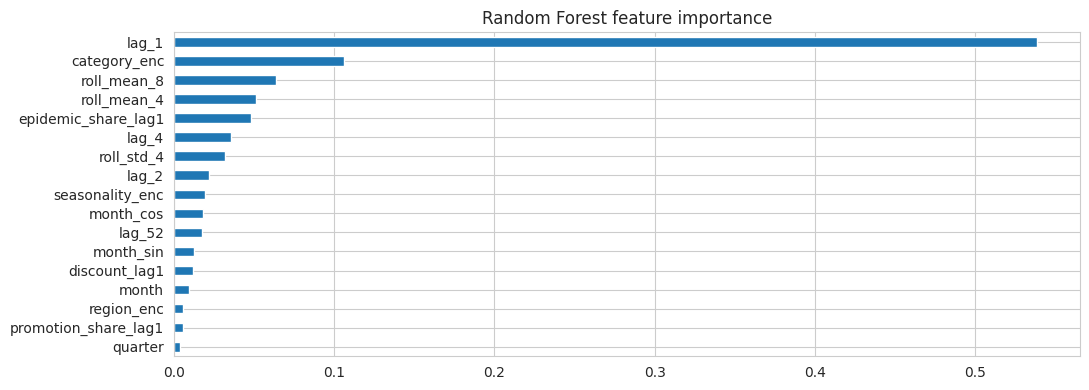

In [5]:
rf = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
holdout['rf_forecast'] = rf.predict(X_holdout)

rf_rmse = np.sqrt(mean_squared_error(y_holdout, holdout['rf_forecast']))
rf_wape = wape(y_holdout, holdout['rf_forecast'])
print(f"Random Forest  - RMSE: {rf_rmse:.2f}  WAPE: {rf_wape:.3f}")

pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values().plot(kind='barh', title='Random Forest feature importance')
plt.tight_layout(); plt.show()

## Step 5 — XGBoost

In [6]:
xgb = XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
holdout['xgb_forecast'] = xgb.predict(X_holdout)

xgb_rmse = np.sqrt(mean_squared_error(y_holdout, holdout['xgb_forecast']))
xgb_wape = wape(y_holdout, holdout['xgb_forecast'])
print(f"XGBoost        - RMSE: {xgb_rmse:.2f}  WAPE: {xgb_wape:.3f}")

XGBoost        - RMSE: 178.38  WAPE: 0.242


## Step 6 — LightGBM

In [7]:
lgbm = LGBMRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42, verbosity=-1)
lgbm.fit(X_train, y_train)
holdout['lgbm_forecast'] = lgbm.predict(X_holdout)

lgbm_rmse = np.sqrt(mean_squared_error(y_holdout, holdout['lgbm_forecast']))
lgbm_wape = wape(y_holdout, holdout['lgbm_forecast'])
print(f"LightGBM       - RMSE: {lgbm_rmse:.2f}  WAPE: {lgbm_wape:.3f}")

LightGBM       - RMSE: 172.36  WAPE: 0.234


## Step 7 — Panel-level comparison (all 100 SKU-stores, holdout WAPE)

                       Model      WAPE        RMSE
0              Random Forest  0.212893  158.642689
1                   LightGBM  0.233647  172.361568
2                    XGBoost  0.241888  178.377042
3  Seasonal-naive (baseline)  0.281619  207.146341


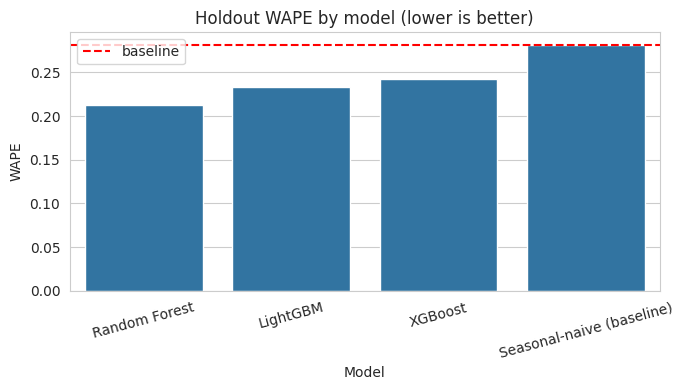

In [8]:
panel_results = pd.DataFrame({
    'Model': ['Seasonal-naive (baseline)', 'Random Forest', 'XGBoost', 'LightGBM'],
    'WAPE': [baseline_wape, rf_wape, xgb_wape, lgbm_wape],
    'RMSE': [np.sqrt(mean_squared_error(baseline_backtest['units_sold'], baseline_backtest['baseline_forecast'])),
             rf_rmse, xgb_rmse, lgbm_rmse],
})
panel_results = panel_results.sort_values('WAPE').reset_index(drop=True)
print(panel_results)

plt.figure(figsize=(7, 4))
sns.barplot(data=panel_results, x='Model', y='WAPE')
plt.axhline(baseline_wape, color='red', linestyle='--', label='baseline')
plt.title('Holdout WAPE by model (lower is better)')
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout(); plt.show()

## Step 8 — Classical time-series models (per-series demo)

ARIMA, SARIMA, Prophet and LSTM are univariate — each one models a *single* series, so
fitting all 100 store-product series individually is a much bigger job than the panel models
above. As a technique demo (matching the course's stock-market example), we run all four on
the single highest-volume store-product series and compare them against that same series'
baseline and panel-model results.

In [9]:
top_sku = weekly.groupby(['store_id', 'product_id'])['units_sold'].sum().idxmax()
sample_store, sample_product = top_sku
print(f"Demo series: store={sample_store}, product={sample_product}")

series_df = weekly[(weekly['store_id'] == sample_store) & (weekly['product_id'] == sample_product)].sort_values('week')
series = series_df.set_index('week')['units_sold']

train_series = series[~series.index.isin(HOLDOUT_WEEKS)]
holdout_series = series[series.index.isin(HOLDOUT_WEEKS)]
print(f"Train weeks: {len(train_series)}  Holdout weeks: {len(holdout_series)}")

sample_baseline = baseline_backtest[(baseline_backtest['store_id'] == sample_store) &
                                     (baseline_backtest['product_id'] == sample_product)]
sample_baseline_wape = wape(sample_baseline['units_sold'], sample_baseline['baseline_forecast'])
print(f"Baseline WAPE on this one series: {sample_baseline_wape:.3f}")

Demo series: store=S001, product=P0003
Train weeks: 102  Holdout weeks: 6
Baseline WAPE on this one series: 0.258


### ARIMA (Statsmodels)

ARIMA          - RMSE: 183.55  WAPE: 0.178


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


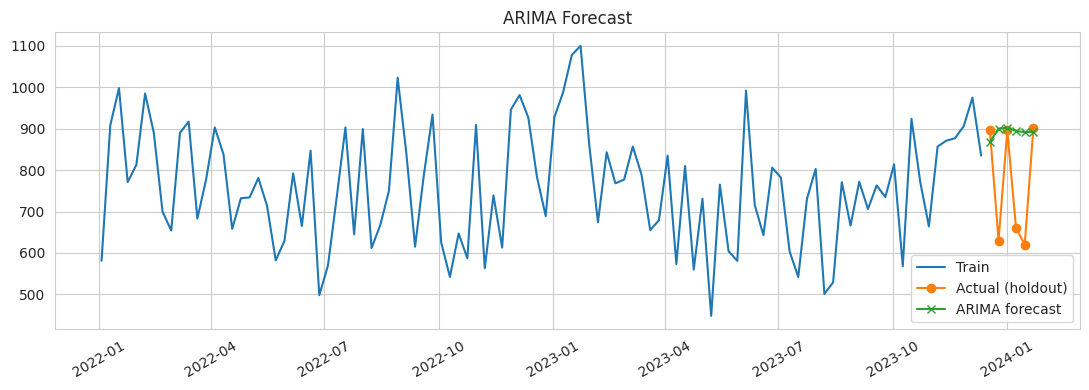

In [10]:
arima_model = ARIMA(train_series, order=(2, 1, 2))
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(steps=len(holdout_series))
arima_forecast.index = holdout_series.index

arima_rmse = np.sqrt(mean_squared_error(holdout_series, arima_forecast))
arima_wape = wape(holdout_series, arima_forecast)
print(f"ARIMA          - RMSE: {arima_rmse:.2f}  WAPE: {arima_wape:.3f}")

plt.plot(train_series.index, train_series, label='Train')
plt.plot(holdout_series.index, holdout_series, label='Actual (holdout)', marker='o')
plt.plot(arima_forecast.index, arima_forecast, label='ARIMA forecast', marker='x')
plt.title('ARIMA Forecast'); plt.legend(); plt.xticks(rotation=30); plt.tight_layout(); plt.show()

### SARIMA (with annual seasonality, s=52 weeks)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


SARIMA         - RMSE: 174.82  WAPE: 0.167


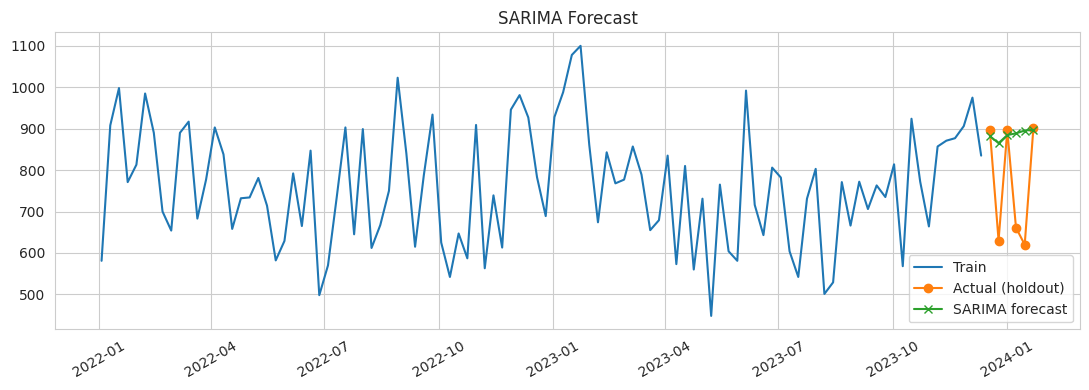

In [11]:
sarima_model = SARIMAX(train_series, order=(1, 1, 1), seasonal_order=(1, 0, 0, 52),
                        enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)
sarima_forecast = sarima_fit.get_forecast(steps=len(holdout_series)).predicted_mean
sarima_forecast.index = holdout_series.index

sarima_rmse = np.sqrt(mean_squared_error(holdout_series, sarima_forecast))
sarima_wape = wape(holdout_series, sarima_forecast)
print(f"SARIMA         - RMSE: {sarima_rmse:.2f}  WAPE: {sarima_wape:.3f}")

plt.plot(train_series.index, train_series, label='Train')
plt.plot(holdout_series.index, holdout_series, label='Actual (holdout)', marker='o')
plt.plot(sarima_forecast.index, sarima_forecast, label='SARIMA forecast', marker='x')
plt.title('SARIMA Forecast'); plt.legend(); plt.xticks(rotation=30); plt.tight_layout(); plt.show()

### Prophet

12:45:15 - cmdstanpy - INFO - Chain [1] start processing


12:45:15 - cmdstanpy - INFO - Chain [1] done processing


Prophet        - RMSE: 199.55  WAPE: 0.223


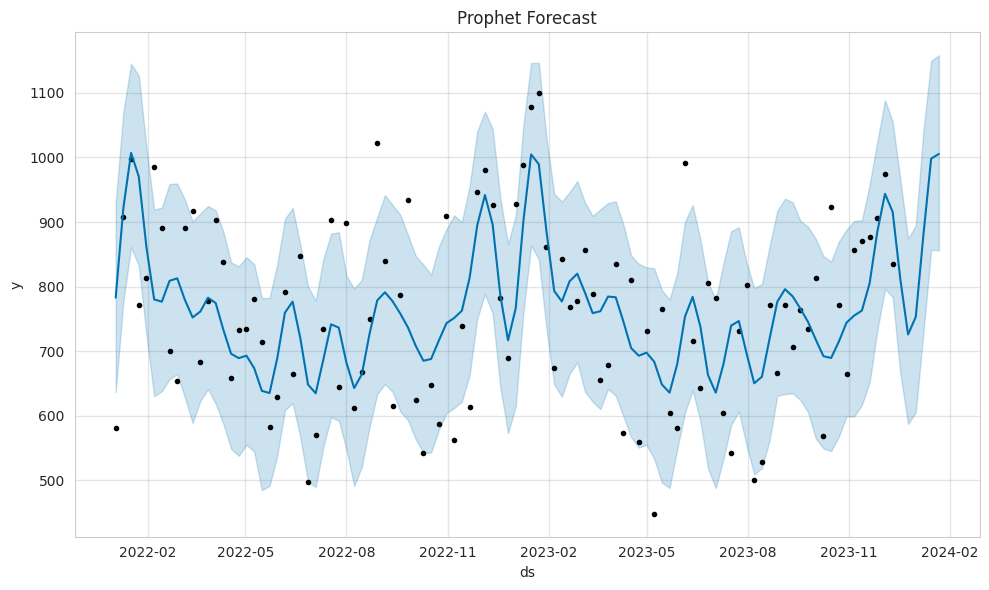

In [12]:
prophet_train = train_series.reset_index().rename(columns={'week': 'ds', 'units_sold': 'y'})

prophet_model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=len(holdout_series), freq='W-MON')
prophet_forecast = prophet_model.predict(future)
prophet_holdout_forecast = prophet_forecast.set_index('ds')['yhat'].reindex(holdout_series.index)

prophet_rmse = np.sqrt(mean_squared_error(holdout_series, prophet_holdout_forecast))
prophet_wape = wape(holdout_series, prophet_holdout_forecast)
print(f"Prophet        - RMSE: {prophet_rmse:.2f}  WAPE: {prophet_wape:.3f}")

fig = prophet_model.plot(prophet_forecast)
plt.title('Prophet Forecast'); plt.tight_layout(); plt.show()

### LSTM (TensorFlow/Keras)

LSTM trained.


LSTM           - RMSE: 138.84  WAPE: 0.170


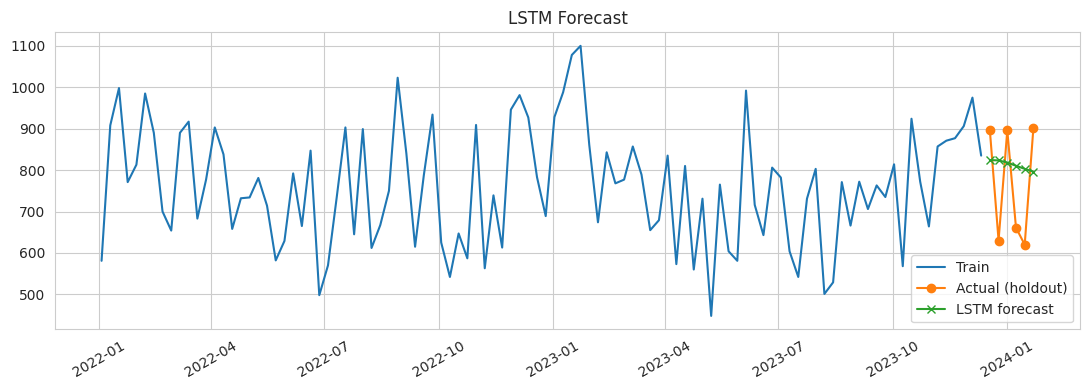

In [13]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(train_series.values.reshape(-1, 1))

TIME_STEP = 8  # weeks of lookback - short on purpose, series is only ~100 weeks long

def create_dataset(dataset, time_step):
    X, y = [], []
    for i in range(len(dataset) - time_step):
        X.append(dataset[i:i + time_step, 0])
        y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(y)

X_lstm, y_lstm = create_dataset(scaled, TIME_STEP)
X_lstm = X_lstm.reshape(X_lstm.shape[0], X_lstm.shape[1], 1)

lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(TIME_STEP, 1)),
    LSTM(50),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mean_squared_error')
lstm_model.fit(X_lstm, y_lstm, epochs=60, batch_size=8, verbose=0)
print("LSTM trained.")

# Recursive multi-step forecast: predict one week, feed it back in, repeat for the 6 holdout weeks
window = scaled[-TIME_STEP:].reshape(1, TIME_STEP, 1)
lstm_scaled_forecast = []
for _ in range(len(holdout_series)):
    next_val = lstm_model.predict(window, verbose=0)[0, 0]
    lstm_scaled_forecast.append(next_val)
    window = np.append(window[:, 1:, :], [[[next_val]]], axis=1)

lstm_forecast = scaler.inverse_transform(np.array(lstm_scaled_forecast).reshape(-1, 1)).flatten()
lstm_forecast = pd.Series(lstm_forecast, index=holdout_series.index)

lstm_rmse = np.sqrt(mean_squared_error(holdout_series, lstm_forecast))
lstm_wape = wape(holdout_series, lstm_forecast)
print(f"LSTM           - RMSE: {lstm_rmse:.2f}  WAPE: {lstm_wape:.3f}")

plt.plot(train_series.index, train_series, label='Train')
plt.plot(holdout_series.index, holdout_series, label='Actual (holdout)', marker='o')
plt.plot(lstm_forecast.index, lstm_forecast, label='LSTM forecast', marker='x')
plt.title('LSTM Forecast'); plt.legend(); plt.xticks(rotation=30); plt.tight_layout(); plt.show()

## Step 9 — All models, same single series (fair one-to-one comparison)

Series: store=S001, product=P0003
                       Model      WAPE
0                    XGBoost  0.155113
1                   LightGBM  0.159170
2                     SARIMA  0.166868
3                       LSTM  0.169693
4              Random Forest  0.174588
5                      ARIMA  0.177860
6                    Prophet  0.222683
7  Seasonal-naive (baseline)  0.257763


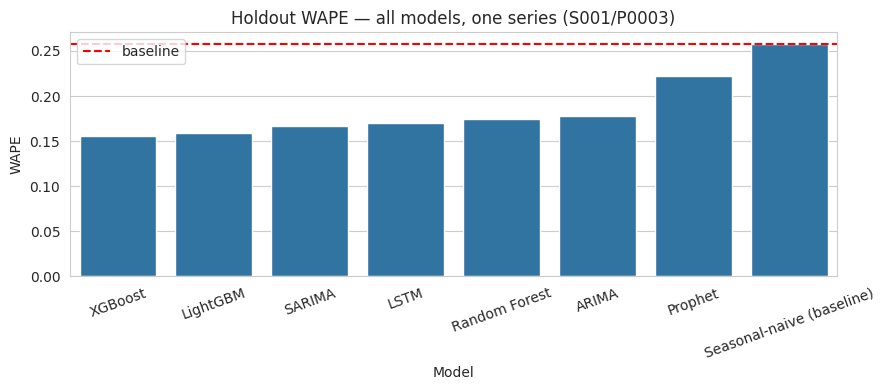

In [14]:
sample_rf = holdout[(holdout['store_id'] == sample_store) & (holdout['product_id'] == sample_product)]

sample_results = pd.DataFrame({
    'Model': ['Seasonal-naive (baseline)', 'Random Forest', 'XGBoost', 'LightGBM',
              'ARIMA', 'SARIMA', 'Prophet', 'LSTM'],
    'WAPE': [
        sample_baseline_wape,
        wape(sample_rf['units_sold'], sample_rf['rf_forecast']),
        wape(sample_rf['units_sold'], sample_rf['xgb_forecast']),
        wape(sample_rf['units_sold'], sample_rf['lgbm_forecast']),
        arima_wape, sarima_wape, prophet_wape, lstm_wape,
    ],
}).sort_values('WAPE').reset_index(drop=True)

print(f"Series: store={sample_store}, product={sample_product}")
print(sample_results)

plt.figure(figsize=(9, 4))
sns.barplot(data=sample_results, x='Model', y='WAPE')
plt.axhline(sample_baseline_wape, color='red', linestyle='--', label='baseline')
plt.title(f'Holdout WAPE — all models, one series ({sample_store}/{sample_product})')
plt.xticks(rotation=20); plt.legend(); plt.tight_layout(); plt.show()

## Step 10 — Save outputs

In [15]:
holdout[['store_id', 'product_id', 'week', 'units_sold', 'baseline_forecast',
         'rf_forecast', 'xgb_forecast', 'lgbm_forecast']].to_csv('../CSV Outputs/ml_forecast_holdout.csv', index=False)

panel_results.to_csv('../CSV Outputs/ml_model_comparison_panel.csv', index=False)
sample_results.to_csv('../CSV Outputs/ml_model_comparison_sample_series.csv', index=False)

print("Saved: ml_forecast_holdout.csv, ml_model_comparison_panel.csv, ml_model_comparison_sample_series.csv")

Saved: ml_forecast_holdout.csv, ml_model_comparison_panel.csv, ml_model_comparison_sample_series.csv


## Summary — Step 7 (Machine Learning Forecast) delivered

| Item | Result |
|---|---|
| Baseline to beat | Seasonal-naive WAPE (see Step 1 output above) |
| Panel models trained | Random Forest, XGBoost, LightGBM — all 100 store-product series, same 6-week holdout as the baseline |
| Classical models (demo) | ARIMA, SARIMA, Prophet, LSTM — single top-volume series, same holdout |
| Best panel model | See `panel_results`, sorted by WAPE, above |
| Preprocessing used | `SimpleImputer` (median) for early-history lag/rolling gaps, `LabelEncoder` for category/region/seasonality, `MinMaxScaler` for the LSTM input |
| Leakage guard kept | Only `*_lag1` promo/discount/epidemic features used, matching notebook 03's flag — the `_UNVERIFIED`/`DO_NOT_USE` columns were excluded |

**Next step (workflow item 8/9):** take the winning model's forecast, turn forecast + days-of-cover
into Reorder / Clear / Hold risk flags, then feed both into the Streamlit dashboard.